--- STAGE 1: Extracting Image Features ---
Processing LA...
Processing HA...
--- STAGE 2: Building Balanced Graph (k=12) ---
--- STAGE 3: Training (Extended Cycle) ---
Epoch 000, Loss: 1.1244
Epoch 050, Loss: 0.4887
Epoch 100, Loss: 0.4700
Epoch 150, Loss: 0.4613
Epoch 200, Loss: 0.4459
Epoch 250, Loss: 0.4346
Epoch 300, Loss: 0.4286
Epoch 350, Loss: 0.4140
Epoch 400, Loss: 0.4039
Epoch 450, Loss: 0.3930
Epoch 500, Loss: 0.3802

--- STAGE 4: Final Evaluation ---
              precision    recall  f1-score   support

         Low       0.54      0.94      0.68       562
        High       0.88      0.37      0.52       720

    accuracy                           0.62      1282
   macro avg       0.71      0.65      0.60      1282
weighted avg       0.73      0.62      0.59      1282

ROC AUC Score: 0.6033


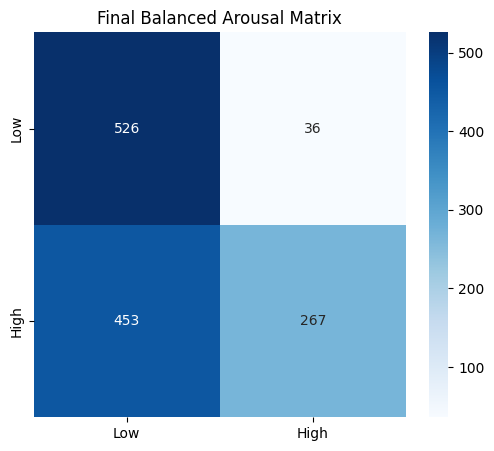

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os, glob, gc
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Arousal_PR_2classes"
BATCH_SIZE = 16 


print("--- STAGE 1: Extracting Image Features ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_data():
    train_feats, train_labs = [], []
    test_feats, test_labs = [], []
    subfolders = {'LA': 0, 'HA': 1} 
    for sub, label in subfolders.items():
        folder_path = os.path.join(base_path, sub)
        images = glob.glob(os.path.join(folder_path, "*.*"))
        print(f"Processing {sub}...")
        for i in range(0, len(images), BATCH_SIZE):
            batch_paths = images[i:i + BATCH_SIZE]
            batch_tensors = []
            for p in batch_paths:
                try:
                    with Image.open(p) as img:
                        batch_tensors.append(transform(img.convert('RGB')))
                except: continue
            if not batch_tensors: continue
            input_batch = torch.stack(batch_tensors).to(device)
            with torch.no_grad():
                feats = model_ft(input_batch).cpu()
            split = int(len(feats) * 0.8)
            train_feats.append(feats[:split]); test_feats.append(feats[split:])
            train_labs.extend([label] * len(feats[:split])); test_labs.extend([label] * len(feats[split:]))
            del input_batch, feats; torch.cuda.empty_cache(); gc.collect()
    return torch.cat(train_feats), torch.tensor(train_labs).long(), torch.cat(test_feats), torch.tensor(test_labs).long()

x_train, y_train, x_test, y_test = get_data()


print("--- STAGE 2: Building Balanced Graph (k=12) ---")
def build_knn(x, k=12): 
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=build_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=build_knn(x_test), y=y_test).to(device)


class EmotionGNN(torch.nn.Module):
    def __init__(self):
        super(EmotionGNN, self).__init__()
        # Using 8 heads to capture more attention variants
        self.conv1 = GATv2Conv(512, 128, heads=8, concat=True)
        self.bn1 = BatchNorm(1024) # 128 * 8
        self.conv2 = GATv2Conv(1024, 2, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.5, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = EmotionGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

class_weights = torch.tensor([2.8, 1.0]).to(device) 


print("--- STAGE 3: Training (Extended Cycle) ---")
model.train()
for epoch in range(501):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')


print("\n--- STAGE 4: Final Evaluation ---")
model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1).cpu()
    y_true = test_data.y.cpu()
    probs = torch.exp(logits)[:, 1].cpu()
    
    print(classification_report(y_true, pred, target_names=['Low', 'High']))
    print(f"ROC AUC Score: {roc_auc_score(y_true, probs):.4f}")
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, pred), annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    plt.title('Final Balanced Arousal Matrix')
    plt.show()

--- STAGE 1: Scanning Folders ---
Processing LD: 970 images...
Processing HD: 4160 images...
--- STAGE 2: Building Graph ---
--- STAGE 3: Training ---
Epoch 000, Loss: 1.2255
Epoch 050, Loss: 0.4709
Epoch 100, Loss: 0.4498
Epoch 150, Loss: 0.4398
Epoch 200, Loss: 0.4143
Epoch 250, Loss: 0.4038
Epoch 300, Loss: 0.3839

--- STAGE 4: Final Evaluation ---
              precision    recall  f1-score   support

         Low       0.16      0.10      0.12       242
        High       0.81      0.89      0.84      1040

    accuracy                           0.74      1282
   macro avg       0.48      0.49      0.48      1282
weighted avg       0.69      0.74      0.71      1282

ROC AUC: 0.5660


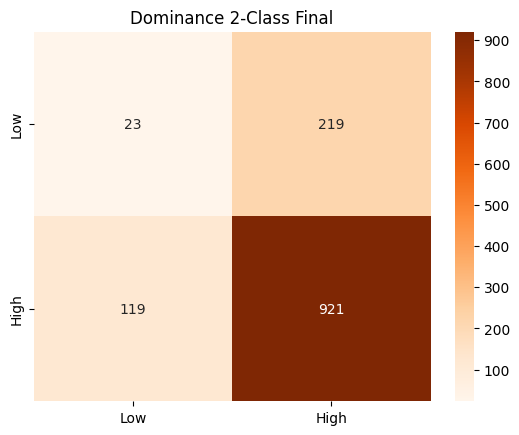

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os, glob, gc
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_PR_2classes"
BATCH_SIZE = 16 

print("--- STAGE 1: Scanning Folders ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_data():
    train_feats, train_labs = [], []
    test_feats, test_labs = [], []
    subfolders = {'LD': 0, 'HD': 1} 
    
    for sub, label in subfolders.items():
        folder_path = os.path.join(base_path, sub)
        images = glob.glob(os.path.join(folder_path, "*.*"))
        print(f"Processing {sub}: {len(images)} images...")
        
        for i in range(0, len(images), BATCH_SIZE):
            batch_paths = images[i:i + BATCH_SIZE]
            batch_tensors = [transform(Image.open(p).convert('RGB')) for p in batch_paths if os.path.exists(p)]
            
            if not batch_tensors: continue
            input_batch = torch.stack(batch_tensors).to(device)
            with torch.no_grad():
                feats = model_ft(input_batch).cpu()
            
            split = int(len(feats) * 0.8)
            train_feats.append(feats[:split]); test_feats.append(feats[split:])
            train_labs.extend([label] * len(feats[:split])); test_labs.extend([label] * len(feats[split:]))
            
            del input_batch, feats
            torch.cuda.empty_cache()
            if i % 800 == 0: gc.collect()

    return torch.cat(train_feats), torch.tensor(train_labs).long(), \
           torch.cat(test_feats), torch.tensor(test_labs).long()

x_train, y_train, x_test, y_test = get_data()


print("--- STAGE 2: Building Graph ---")
def build_knn(x, k=10): 
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=build_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=build_knn(x_test), y=y_test).to(device)


class EmotionGNN(torch.nn.Module):
    def __init__(self):
        super(EmotionGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(512)
        self.conv2 = GATv2Conv(512, 2, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.4, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = EmotionGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Balanced 1.2 weight for Dominance imbalanced data
class_weights = torch.tensor([1.2, 1.0]).to(device) 

print("--- STAGE 3: Training ---")
model.train()
for epoch in range(301):
    optimizer.zero_grad()
    loss = F.nll_loss(model(train_data), train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')


print("\n--- STAGE 4: Final Evaluation ---")
model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1).cpu()
    y_true = test_data.y.cpu()
    
    print(classification_report(y_true, pred, target_names=['Low', 'High']))
    print(f"ROC AUC: {roc_auc_score(y_true, torch.exp(logits)[:, 1].cpu()):.4f}")
    
    sns.heatmap(confusion_matrix(y_true, pred), annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    plt.title("Dominance 2-Class Final")
    plt.show()

--- STAGE 1: Scanning Valence Folders ---
Processing LV: 400 images...
Processing HV: 4720 images...
--- STAGE 2: Building Balanced Graph ---
--- STAGE 3: Training Balanced Model ---
Epoch 000, Loss: 1.1741
Epoch 050, Loss: 0.4640
Epoch 100, Loss: 0.4201
Epoch 150, Loss: 0.3726
Epoch 200, Loss: 0.3018
Epoch 250, Loss: 0.2211
Epoch 300, Loss: 0.1505
Epoch 350, Loss: 0.1127
Epoch 400, Loss: 0.0811

              precision    recall  f1-score   support

         Low       0.09      0.15      0.11       100
        High       0.92      0.87      0.90      1180

    accuracy                           0.81      1280
   macro avg       0.51      0.51      0.50      1280
weighted avg       0.86      0.81      0.83      1280

ROC AUC Score: 0.5408


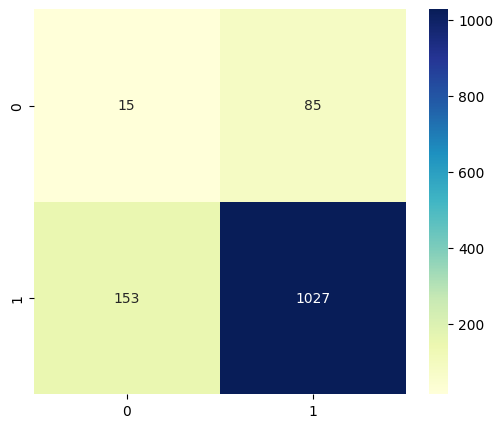

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os, glob, gc
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_2classes"
BATCH_SIZE = 16 


print("--- STAGE 1: Scanning Valence Folders ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_data():
    train_feats, train_labs = [], []
    test_feats, test_labs = [], []
    subfolders = {'LV': 0, 'HV': 1} 
    
    for sub, label in subfolders.items():
        folder_path = os.path.join(base_path, sub)
        images = glob.glob(os.path.join(folder_path, "*.*"))
        print(f"Processing {sub}: {len(images)} images...")
        
        for i in range(0, len(images), BATCH_SIZE):
            batch_paths = images[i:i + BATCH_SIZE]
            batch_tensors = [transform(Image.open(p).convert('RGB')) for p in batch_paths if os.path.exists(p)]
            
            if not batch_tensors: continue
            input_batch = torch.stack(batch_tensors).to(device)
            with torch.no_grad():
                feats = model_ft(input_batch).cpu()
            
            split = int(len(feats) * 0.8)
            train_feats.append(feats[:split]); test_feats.append(feats[split:])
            train_labs.extend([label] * len(feats[:split])); test_labs.extend([label] * len(feats[split:]))
            
            del input_batch, feats
            torch.cuda.empty_cache()
            if i % 800 == 0: gc.collect()

    return torch.cat(train_feats), torch.tensor(train_labs).long(), \
           torch.cat(test_feats), torch.tensor(test_labs).long()

x_train, y_train, x_test, y_test = get_data()


print("--- STAGE 2: Building Balanced Graph ---")
def build_knn(x, k=12): 
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=build_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=build_knn(x_test), y=y_test).to(device)


class EmotionGNN(torch.nn.Module):
    def __init__(self):
        super(EmotionGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(512)
        self.conv2 = GATv2Conv(512, 2, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.4, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = EmotionGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


class_weights = torch.tensor([4.0, 1.0]).to(device) 


print("--- STAGE 3: Training Balanced Model ---")
model.train()
for epoch in range(401):
    optimizer.zero_grad()
    loss = F.nll_loss(model(train_data), train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')


model.eval()
with torch.no_grad():
    logits = model(test_data)
    pred = logits.argmax(dim=1).cpu()
    y_true = test_data.y.cpu()
    
    print("\n" + classification_report(y_true, pred, target_names=['Low', 'High']))
    print(f"ROC AUC Score: {roc_auc_score(y_true, torch.exp(logits)[:, 1].cpu()):.4f}")
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, pred), annot=True, fmt='d', cmap='YlGnBu')
    plt.show()

--- STAGE 1: Fast Feature Extraction ---
Scanning LV...
Scanning MV...
Scanning HV...
--- STAGE 2: Building Light Graph ---
--- STAGE 3: Quick Training ---
Epoch 000, Loss: 1.1281
Epoch 050, Loss: 0.8909
Epoch 100, Loss: 0.8129
Epoch 150, Loss: 0.7052

              precision    recall  f1-score   support

          LV       0.00      0.00      0.00        49
          MV       0.14      0.02      0.03       103
          HV       0.85      0.99      0.91       872

    accuracy                           0.84      1024
   macro avg       0.33      0.34      0.32      1024
weighted avg       0.74      0.84      0.78      1024

ROC AUC: 0.6458


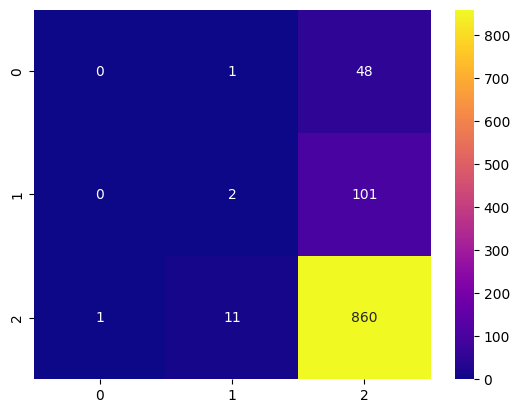

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from PIL import Image
import os, glob, gc
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_3classes"
BATCH_SIZE = 32 


print("--- STAGE 1: Fast Feature Extraction ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_fast_data():
    all_feats, all_labs = [], []
    subfolders = {'LV': 0, 'MV': 1, 'HV': 2}
    
    for sub, label in subfolders.items():
        folder_path = os.path.join(base_path, sub)
        if not os.path.exists(folder_path): continue
        images = glob.glob(os.path.join(folder_path, "*.*"))
        print(f"Scanning {sub}...")
        
        for i in range(0, len(images), BATCH_SIZE):
            batch_paths = images[i:i + BATCH_SIZE]
            batch_tensors = [transform(Image.open(p).convert('RGB')) for p in batch_paths if os.path.exists(p)]
            if not batch_tensors: continue
            
            input_batch = torch.stack(batch_tensors).to(device)
            with torch.no_grad():
                feats = model_ft(input_batch).cpu()
            all_feats.append(feats)
            all_labs.extend([label] * len(feats))
            
    x = torch.cat(all_feats)
    y = torch.tensor(all_labs).long()
    
    indices = torch.randperm(len(x))
    split = int(0.8 * len(x))
    return x[indices[:split]], y[indices[:split]], x[indices[split:]], y[indices[split:]]

x_train, y_train, x_test, y_test = get_fast_data()


print("--- STAGE 2: Building Light Graph ---")
def build_knn_fast(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=build_knn_fast(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=build_knn_fast(x_test), y=y_test).to(device)


class LightGNN(torch.nn.Module):
    def __init__(self):
        super(LightGNN, self).__init__()
        self.conv1 = GCNConv(512, 128)
        self.bn1 = BatchNorm(128)
        self.conv2 = GCNConv(128, 3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = LightGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
class_weights = torch.tensor([5.0, 3.0, 1.0]).to(device) 


print("--- STAGE 3: Quick Training ---")
model.train()
for epoch in range(151):
    optimizer.zero_grad()
    loss = F.nll_loss(model(train_data), train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')


model.eval()
with torch.no_grad():
    logits = model(test_data)
    probs = torch.exp(logits).cpu().numpy()
    pred = logits.argmax(dim=1).cpu().numpy()
    y_true = test_data.y.cpu().numpy()
    
    print("\n" + classification_report(y_true, pred, target_names=['LV', 'MV', 'HV']))
    try:
        print(f"ROC AUC: {roc_auc_score(y_true, probs, multi_class='ovr'):.4f}")
    except: pass
    
    sns.heatmap(confusion_matrix(y_true, pred), annot=True, fmt='d', cmap='plasma')
    plt.show()

--- STAGE 1: Scanning 3-Class Dominance ---
Processing LD: Found 1920 images...
Processing MD: Found 1746 images...
Processing HD: Found 6560 images...

--- STAGE 2: Building 3-Class Web ---

--- STAGE 3: Training Weighted GNN ---
Epoch 000, Loss: 1.7218
Epoch 050, Loss: 0.8696
Epoch 100, Loss: 0.7851
Epoch 150, Loss: 0.7300
Epoch 200, Loss: 0.6424
Epoch 250, Loss: 0.5910

   FINAL 3-CLASS DOMINANCE REPORT
              precision    recall  f1-score   support

         Low       0.41      0.86      0.56       384
         Mid       0.53      0.13      0.20       350
        High       0.92      0.81      0.86      1312

    accuracy                           0.70      2046
   macro avg       0.62      0.60      0.54      2046
weighted avg       0.76      0.70      0.69      2046



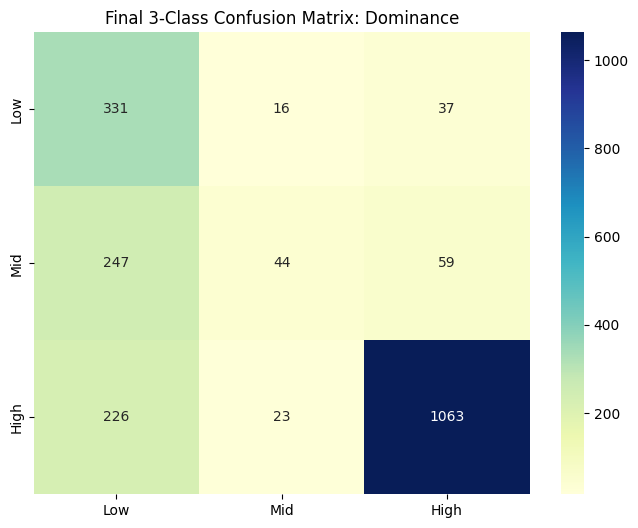

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, BatchNorm
from PIL import Image
import os
import glob
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

base_path = r"G:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_P_3Clases"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("--- STAGE 1: Scanning 3-Class Dominance ---")
model_ft = models.resnet18(weights='IMAGENET1K_V1').to(device)
model_ft.fc = nn.Identity()
model_ft.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_features, train_labels = [], []
test_features, test_labels = [], []
subfolders = {'LD': 0, 'MD': 1, 'HD': 2} 

for sub, label in subfolders.items():
    folder_path = os.path.join(base_path, sub)
    
    images = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.JPG", "*.PNG"]:
        images.extend(glob.glob(os.path.join(folder_path, ext)))
    
    if not images:
        print(f"⚠️ WARNING: No images found in {folder_path}. Please check the folder name.")
        continue

    split_idx = int(len(images) * 0.8)
    print(f"Processing {sub}: Found {len(images)} images...")
    
    for i, img_path in enumerate(images):
        try:
            img = Image.open(img_path).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = model_ft(img_t)
            
            if i < split_idx:
                train_features.append(feat.cpu())
                train_labels.append(label)
            else:
                test_features.append(feat.cpu())
                test_labels.append(label)
        except Exception as e:
            continue

if not train_features:
    raise ValueError("No images were successfully scanned. Check your 'base_path'.")

x_train, y_train = torch.cat(train_features), torch.tensor(train_labels).long()
x_test, y_test = torch.cat(test_features), torch.tensor(test_labels).long()

print("\n--- STAGE 2: Building 3-Class Web ---")
def manual_knn(x, k=5):
    dist = torch.cdist(x, x)
    _, indices = dist.topk(k + 1, largest=False)
    row = torch.arange(indices.shape[0]).view(-1, 1).repeat(1, k).view(-1)
    col = indices[:, 1:].reshape(-1)
    return torch.stack([row, col], dim=0)

train_data = Data(x=x_train, edge_index=manual_knn(x_train), y=y_train).to(device)
test_data = Data(x=x_test, edge_index=manual_knn(x_test), y=y_test).to(device)

class_weights = torch.tensor([12.0, 6.0, 1.0]).to(device) 

class FinalDominanceGNN(torch.nn.Module):
    def __init__(self):
        super(FinalDominanceGNN, self).__init__()
        self.conv1 = GATv2Conv(512, 128, heads=4, concat=True)
        self.bn1 = BatchNorm(128 * 4)
        self.conv2 = GATv2Conv(128 * 4, 3, heads=1, concat=False) 

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = FinalDominanceGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\n--- STAGE 3: Training Weighted GNN ---")
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.nll_loss(out, train_data.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    pred = model(test_data).argmax(dim=1).cpu()
    print("\n" + "="*30)
    print("   FINAL 3-CLASS DOMINANCE REPORT")
    print("="*30)
    print(classification_report(y_test, pred, target_names=['Low', 'Mid', 'High']))
    
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
    plt.title('Final 3-Class Confusion Matrix: Dominance')
    plt.show()